Shape: (40000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40000 non-null  object 
 1   rating    40000 non-null  float64
 2   label     40000 non-null  object 
 3   text_     40000 non-null  object 
 4   user_id   40000 non-null  int64  
 5   date      40000 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.8+ MB
None
                       category  rating label  \
0  Tools_and_Home_Improvement_5     5.0    CG   
1               Movies_and_TV_5     5.0    CG   
2                       Books_5     5.0    OR   
3              Toys_and_Games_5     4.0    CG   
4                 Electronics_5     5.0    CG   

                                               text_  user_id        date  
0  This is a must-buy fixture if you want everyth...    10249  2022-09-13  
1  This product feels premium and gives you a si

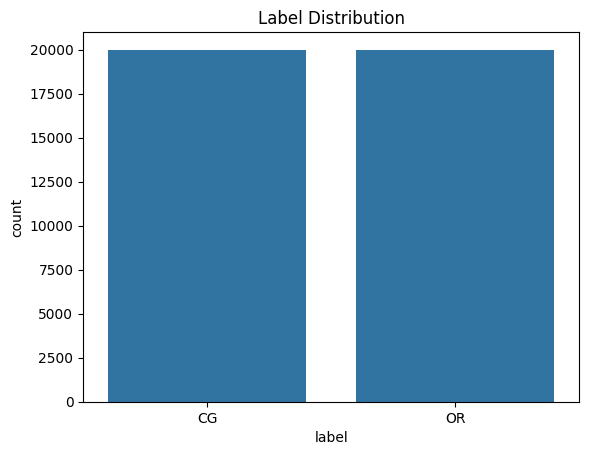

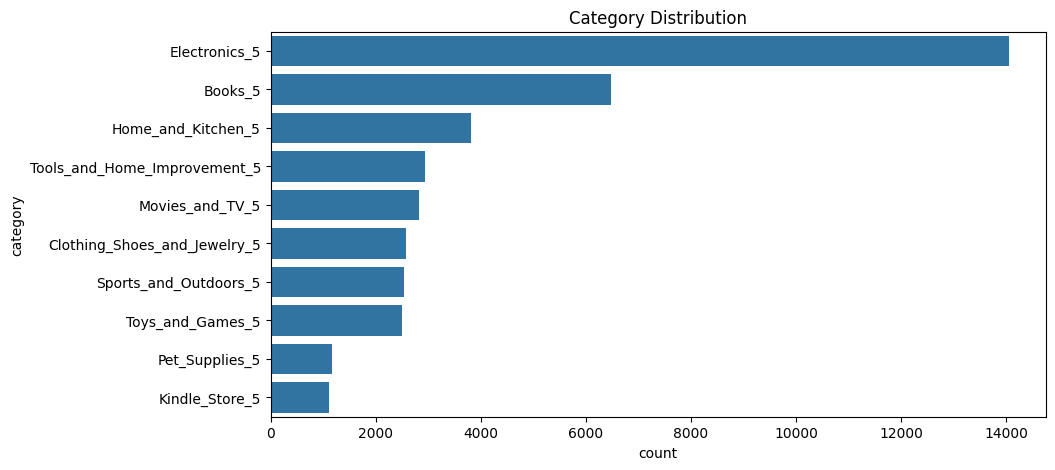

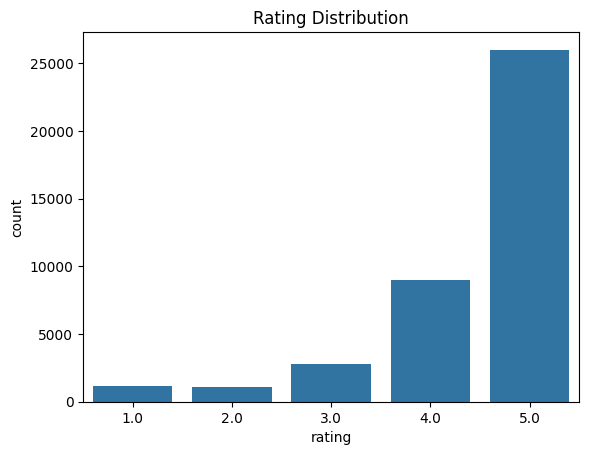


Text Length Stats:
        char_length    word_count
count  40000.000000  40000.000000
mean     277.814525     49.162850
std       47.741911      9.471205
min      153.000000     25.000000
25%      242.000000     42.000000
50%      278.000000     48.000000
75%      311.000000     56.000000
max      470.000000     85.000000


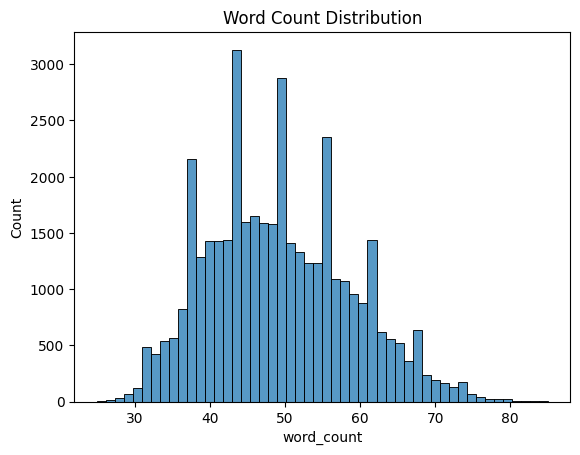

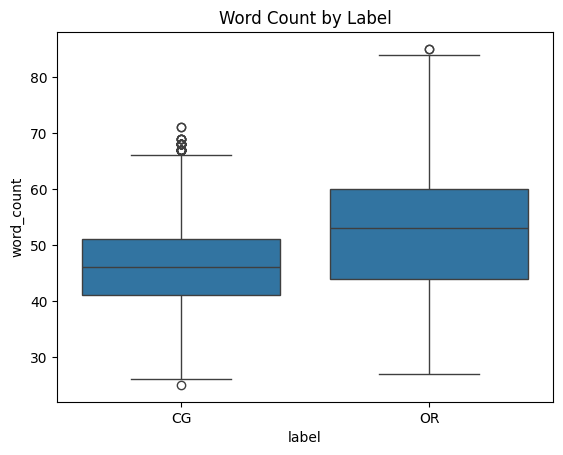


Top CG Words:
 [('the', 60119), ('is', 50898), ('and', 35624), ('a', 30076), ('it', 29989), ('that', 20124), ('this', 19883), ('feels', 17395), ('easy', 15284), ('experience', 14981), ('you', 14115), ('for', 12128), ('an', 11847), ('from', 11768), ('one', 11544), ('premium', 11116), ('to', 10032), ('in', 9363), ('overall', 9248), ('impressive', 8875)]

Top OR Words:
 [('it', 63218), ('the', 53888), ('i', 48548), ('is', 46032), ('for', 36222), ('that', 31964), ('a', 30100), ('and', 16404), ('to', 13762), ('use', 12427), ('was', 12200), ('this', 12090), ('so', 11357), ('difference', 11134), ('with', 10999), ('than', 10030), ('in', 9493), ('my', 8712), ('compared', 8066), ('of', 7917)]


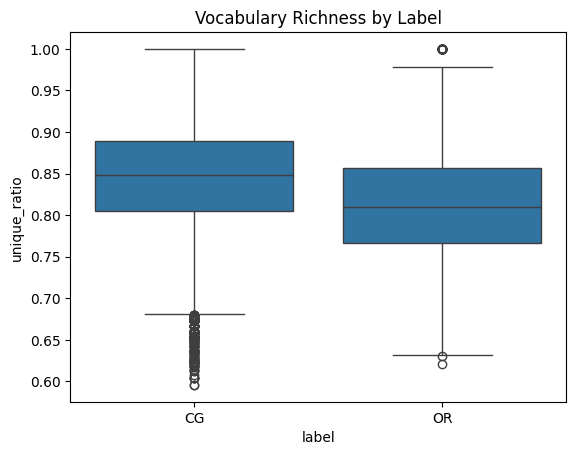

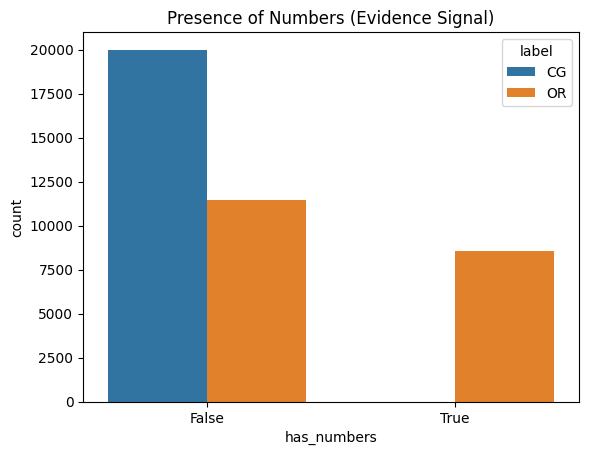

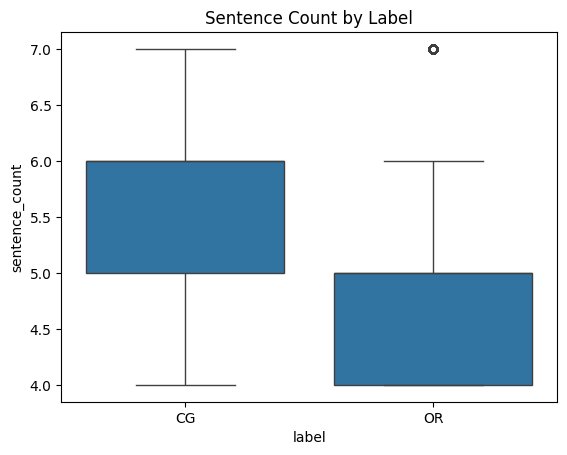

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


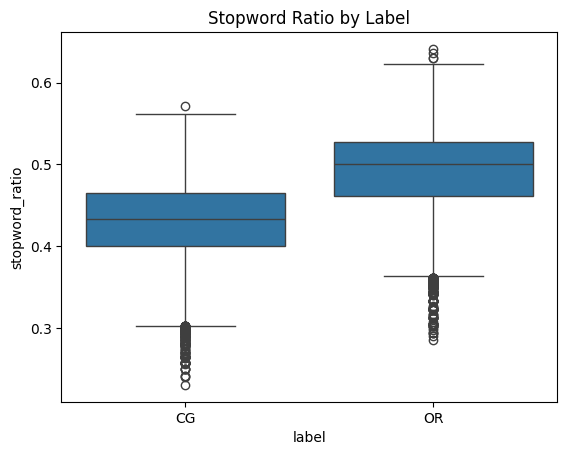


Duplicate texts: 0


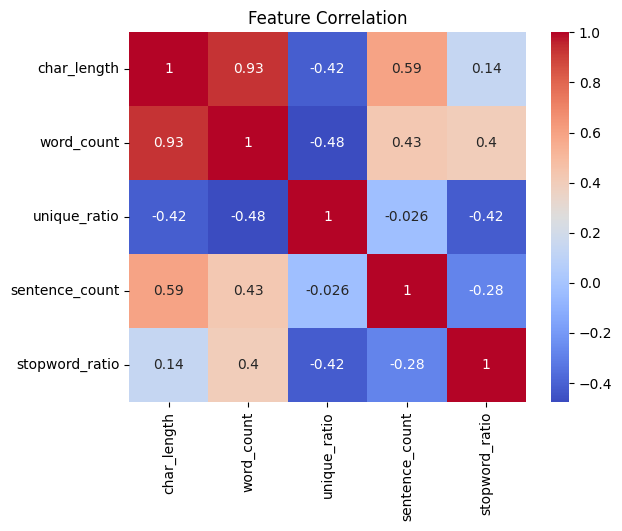


=== INSIGHTS ===
1. CG reviews should have lower unique ratio and higher repetition.
2. OR reviews should show more numbers and sentence diversity.
3. If overlap is high → your dataset is still weak.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Load dataset
df = pd.read_csv("curated_reviews_40k_perfectish.csv")

# Basic Info
print("Shape:", df.shape)
print(df.info())
print(df.head())

# -----------------------------
# 1. Label Distribution
# -----------------------------
print("\nLabel Distribution:")
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

# -----------------------------
# 2. Category Distribution
# -----------------------------
plt.figure(figsize=(10,5))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index)
plt.title("Category Distribution")
plt.show()

# -----------------------------
# 3. Rating Distribution
# -----------------------------
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.show()

# -----------------------------
# 4. Text Length Analysis
# -----------------------------
df['char_length'] = df['text_'].apply(len)
df['word_count'] = df['text_'].apply(lambda x: len(x.split()))

print("\nText Length Stats:")
print(df[['char_length','word_count']].describe())

# Distribution
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

# Compare CG vs OR
sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count by Label")
plt.show()

# -----------------------------
# 5. Vocabulary Analysis
# -----------------------------
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Top words per class
cg_words = []
or_words = []

for _, row in df.iterrows():
    tokens = tokenize(row['text_'])
    if row['label'] == 'CG':
        cg_words.extend(tokens)
    else:
        or_words.extend(tokens)

cg_common = Counter(cg_words).most_common(20)
or_common = Counter(or_words).most_common(20)

print("\nTop CG Words:\n", cg_common)
print("\nTop OR Words:\n", or_common)

# -----------------------------
# 6. Unique Word Ratio (Richness)
# -----------------------------
def unique_ratio(text):
    words = text.split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

df['unique_ratio'] = df['text_'].apply(unique_ratio)

sns.boxplot(x='label', y='unique_ratio', data=df)
plt.title("Vocabulary Richness by Label")
plt.show()

# -----------------------------
# 7. Numeric Evidence Check
# -----------------------------
def has_numbers(text):
    return bool(re.search(r'\d', text))

df['has_numbers'] = df['text_'].apply(has_numbers)

sns.countplot(x='has_numbers', hue='label', data=df)
plt.title("Presence of Numbers (Evidence Signal)")
plt.show()

# -----------------------------
# 8. Sentence Count Analysis
# -----------------------------
df['sentence_count'] = df['text_'].apply(lambda x: len(re.split(r'[.!?]', x)))

sns.boxplot(x='label', y='sentence_count', data=df)
plt.title("Sentence Count by Label")
plt.show()

# -----------------------------
# 9. Stopword Density (Optional)
# -----------------------------
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def stopword_ratio(text):
    words = text.split()
    if len(words) == 0:
        return 0
    stop_count = sum(1 for w in words if w.lower() in stop_words)
    return stop_count / len(words)

df['stopword_ratio'] = df['text_'].apply(stopword_ratio)

sns.boxplot(x='label', y='stopword_ratio', data=df)
plt.title("Stopword Ratio by Label")
plt.show()

# -----------------------------
# 10. Duplicate Check
# -----------------------------
duplicates = df['text_'].duplicated().sum()
print(f"\nDuplicate texts: {duplicates}")

# -----------------------------
# 11. Correlation Heatmap
# -----------------------------
features = ['char_length','word_count','unique_ratio','sentence_count','stopword_ratio']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# -----------------------------
# 12. Quick Insight Print
# -----------------------------
print("\n=== INSIGHTS ===")
print("1. CG reviews should have lower unique ratio and higher repetition.")
print("2. OR reviews should show more numbers and sentence diversity.")
print("3. If overlap is high → your dataset is still weak.")

Shape: (40432, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
 4   user_id   40432 non-null  int64  
 5   date      40432 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.9+ MB
None
        category  rating label  \
0  Electronics_5     5.0    CG   
1        Books_5     5.0    CG   
2  Electronics_5     5.0    CG   
3  Electronics_5     5.0    CG   
4  Electronics_5     5.0    CG   

                                               text_  user_id        date  
0  Love this!  Well made, sturdy, and very comfor...     4248  2022-07-04  
1  love it, a great upgrade from the original.  I...     8974  2022-12-02  
2  This pillow saved my back. I love the look and...      839 

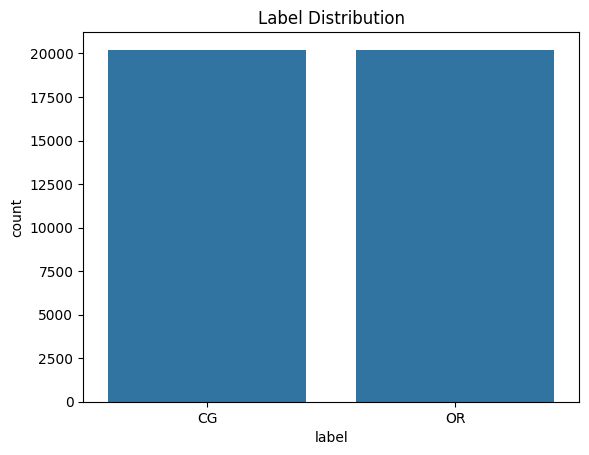

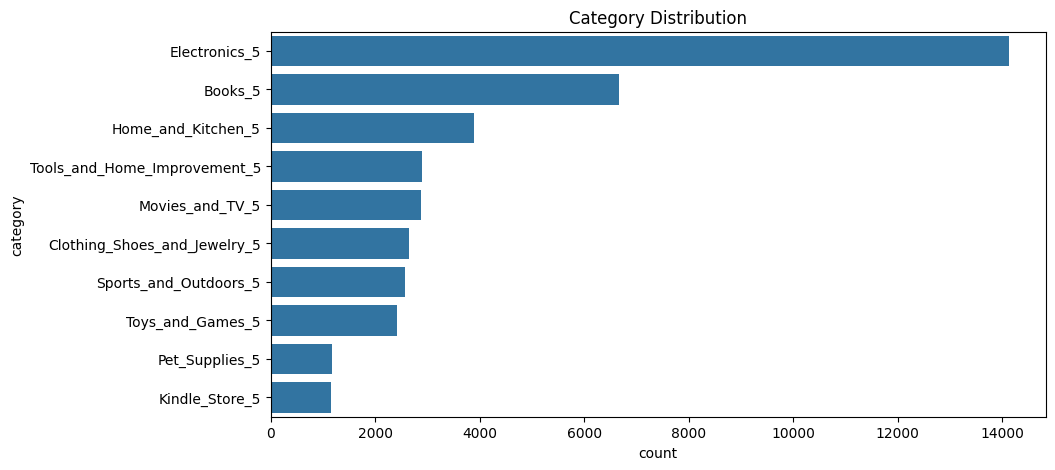

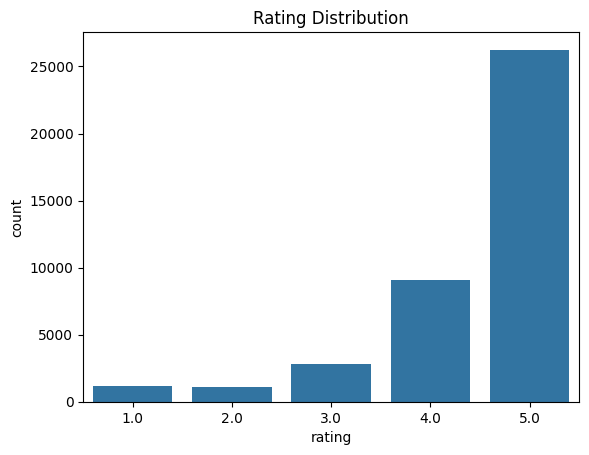


Text Length Stats:
        char_length    word_count
count  40432.000000  40432.000000
mean     350.457855     67.308716
std      369.615590     69.562949
min       24.000000      1.000000
25%      106.000000     21.000000
50%      198.000000     38.000000
75%      438.000000     85.000000
max     2827.000000    373.000000


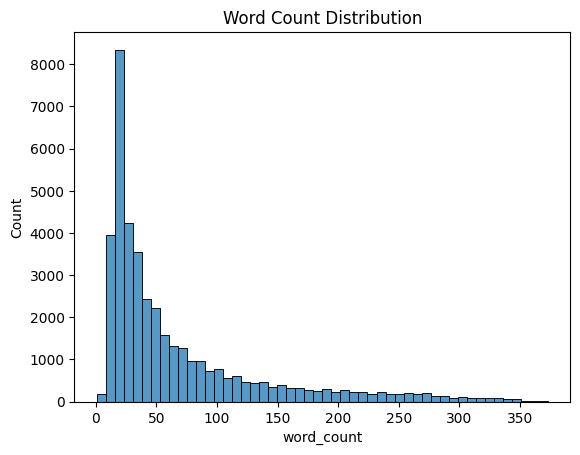

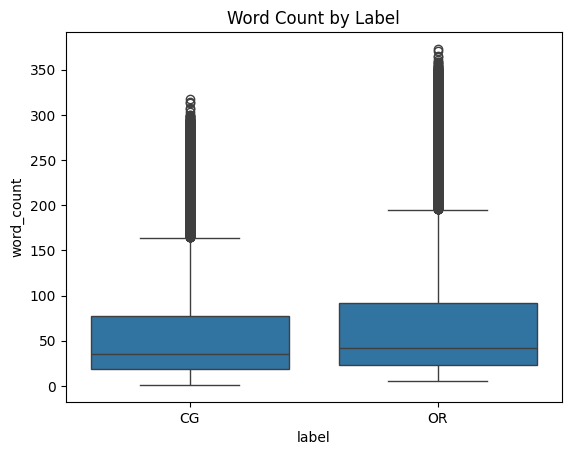


Top CG Words:
 [('the', 83706), ('a', 56829), ('i', 56799), ('and', 43103), ('is', 40412), ('it', 37704), ('to', 30535), ('this', 26755), ('of', 20350), ('for', 20323), ('very', 14708), ('was', 14632), ('have', 13285), ('that', 12234), ('my', 11370), ('in', 11113), ('with', 10781), ('great', 10618), ('are', 10150), ('book', 9770)]

Top OR Words:
 [('the', 73301), ('and', 44258), ('a', 40010), ('i', 39896), ('to', 37833), ('it', 30864), ('of', 25083), ('is', 24335), ('this', 22426), ('for', 18524), ('in', 18431), ('that', 14366), ('my', 13250), ('with', 12808), ('but', 11793), ('was', 11610), ('on', 10908), ('you', 10048), ('have', 9864), ('not', 9580)]


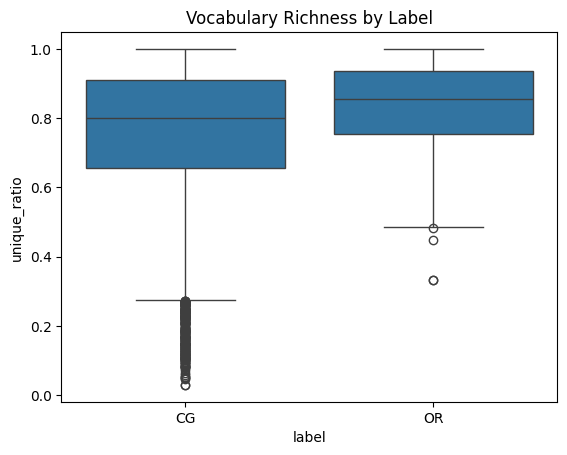

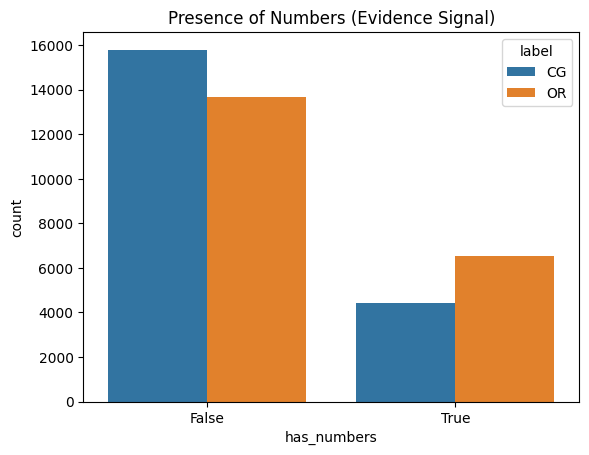

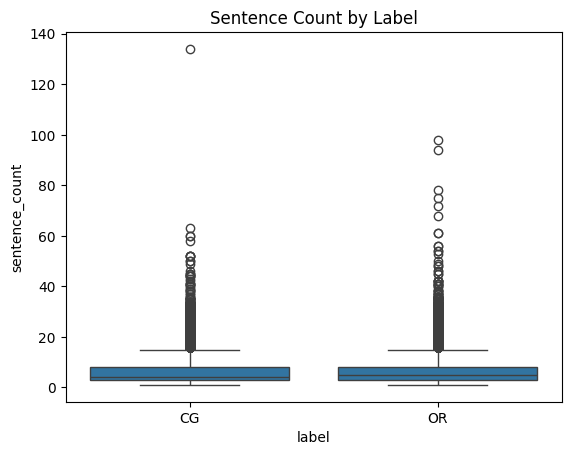

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


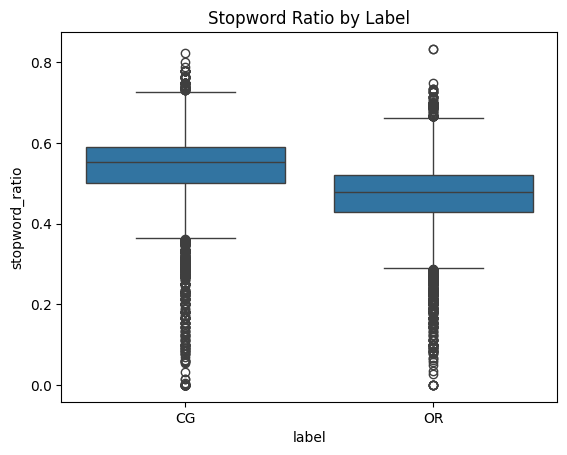


Duplicate texts: 137


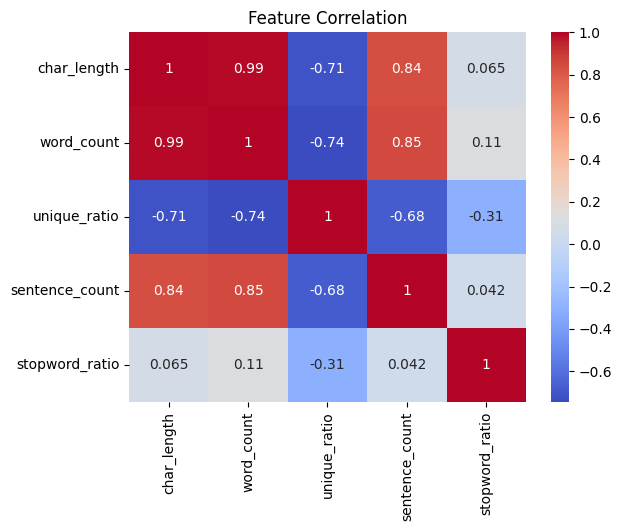


=== INSIGHTS ===
1. CG reviews should have lower unique ratio and higher repetition.
2. OR reviews should show more numbers and sentence diversity.
3. If overlap is high → your dataset is still weak.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Load dataset
df = pd.read_csv("fake_reviews_dataset.csv")

# Basic Info
print("Shape:", df.shape)
print(df.info())
print(df.head())

# -----------------------------
# 1. Label Distribution
# -----------------------------
print("\nLabel Distribution:")
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

# -----------------------------
# 2. Category Distribution
# -----------------------------
plt.figure(figsize=(10,5))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index)
plt.title("Category Distribution")
plt.show()

# -----------------------------
# 3. Rating Distribution
# -----------------------------
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.show()

# -----------------------------
# 4. Text Length Analysis
# -----------------------------
df['char_length'] = df['text_'].apply(len)
df['word_count'] = df['text_'].apply(lambda x: len(x.split()))

print("\nText Length Stats:")
print(df[['char_length','word_count']].describe())

# Distribution
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

# Compare CG vs OR
sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count by Label")
plt.show()

# -----------------------------
# 5. Vocabulary Analysis
# -----------------------------
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Top words per class
cg_words = []
or_words = []

for _, row in df.iterrows():
    tokens = tokenize(row['text_'])
    if row['label'] == 'CG':
        cg_words.extend(tokens)
    else:
        or_words.extend(tokens)

cg_common = Counter(cg_words).most_common(20)
or_common = Counter(or_words).most_common(20)

print("\nTop CG Words:\n", cg_common)
print("\nTop OR Words:\n", or_common)

# -----------------------------
# 6. Unique Word Ratio (Richness)
# -----------------------------
def unique_ratio(text):
    words = text.split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

df['unique_ratio'] = df['text_'].apply(unique_ratio)

sns.boxplot(x='label', y='unique_ratio', data=df)
plt.title("Vocabulary Richness by Label")
plt.show()

# -----------------------------
# 7. Numeric Evidence Check
# -----------------------------
def has_numbers(text):
    return bool(re.search(r'\d', text))

df['has_numbers'] = df['text_'].apply(has_numbers)

sns.countplot(x='has_numbers', hue='label', data=df)
plt.title("Presence of Numbers (Evidence Signal)")
plt.show()

# -----------------------------
# 8. Sentence Count Analysis
# -----------------------------
df['sentence_count'] = df['text_'].apply(lambda x: len(re.split(r'[.!?]', x)))

sns.boxplot(x='label', y='sentence_count', data=df)
plt.title("Sentence Count by Label")
plt.show()

# -----------------------------
# 9. Stopword Density (Optional)
# -----------------------------
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def stopword_ratio(text):
    words = text.split()
    if len(words) == 0:
        return 0
    stop_count = sum(1 for w in words if w.lower() in stop_words)
    return stop_count / len(words)

df['stopword_ratio'] = df['text_'].apply(stopword_ratio)

sns.boxplot(x='label', y='stopword_ratio', data=df)
plt.title("Stopword Ratio by Label")
plt.show()

# -----------------------------
# 10. Duplicate Check
# -----------------------------
duplicates = df['text_'].duplicated().sum()
print(f"\nDuplicate texts: {duplicates}")

# -----------------------------
# 11. Correlation Heatmap
# -----------------------------
features = ['char_length','word_count','unique_ratio','sentence_count','stopword_ratio']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# -----------------------------
# 12. Quick Insight Print
# -----------------------------
print("\n=== INSIGHTS ===")
print("1. CG reviews should have lower unique ratio and higher repetition.")
print("2. OR reviews should show more numbers and sentence diversity.")
print("3. If overlap is high → your dataset is still weak.")